# 01 · Exploratory analysis of the DSWP coda dataset

**Goal:** understand the data before modelling anything. What is in it, how clean is it, and which structure is visible by eye?

**Dataset:** 8,719 annotated codas from the Dominica Sperm Whale Project (2005–2016), published with Sharma et al. (2024), *Nature Communications* 15:3617. Download it first with `python scripts/download_data.py`.

**Key concept.** Sperm whales communicate with *codas*: short sequences of broadband clicks. The information is carried mainly by **timing**, so each coda is described by its inter-click intervals (ICIs), not by a spectrogram. Two derived views matter:

- **rhythm**: ICIs divided by total duration → the *shape* of the coda, independent of speed
- **tempo**: total duration → how *fast* the coda is produced

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from whalecodas import load_codas, filter_codas, rhythm_matrix
from whalecodas.data import PROJECT_ROOT, ICI_COLS

FIG = PROJECT_ROOT / "reports" / "figures"
sns.set_theme(style="whitegrid", context="notebook")
raw = load_codas()
raw.head()

,codaNUM2018,Date,nClicks,Duration,ICI1,ICI2,ICI3,ICI4,ICI5,ICI6,ICI7,ICI8,ICI9,CodaType,Clan,Unit,UnitNum,IDN,is_noise,whale_known
0,1,2005-03-04,5,1.188,0.293,0.282,0.298,0.315,0.0,0.0,0.0,0.0,0.0,5R3,EC1,A,1,0,False,False
1,2,2005-03-04,5,1.125,0.287,0.265,0.299,0.274,0.0,0.0,0.0,0.0,0.0,5R3,EC1,A,1,0,False,False
2,3,2005-03-04,5,1.090,0.264,0.253,0.297,0.276,0.0,0.0,0.0,0.0,0.0,5R3,EC1,A,1,0,False,False
3,4,2005-03-04,5,1.090,0.269,0.265,0.271,0.285,0.0,0.0,0.0,0.0,0.0,5R3,EC1,A,1,0,False,False
4,5,2005-03-04,5,1.101,0.273,0.267,0.266,0.295,0.0,0.0,0.0,0.0,0.0,5R3,EC1,A,1,0,False,False


## 1. Data integrity checks

In [2]:
print("Rows:", len(raw))
print("Missing values:", int(raw.isna().sum().sum()))

ici = raw[ICI_COLS]
print("Non-zero ICIs == nClicks - 1:", f"{((ici > 0).sum(axis=1) == raw.nClicks - 1).mean():.2%}")
print("Max |Duration - sum(ICIs)|:", f"{(raw.Duration - ici.sum(axis=1)).abs().max():.4f} s")
print("Date range:", raw.Date.min().date(), "->", raw.Date.max().date())

Rows: 8719
Missing values: 0
Non-zero ICIs == nClicks - 1: 99.97%
Max |Duration - sum(ICIs)|: 0.0096 s
Date range: 2005-01-15 -> 2016-05-13


The file is internally consistent: ICIs sum to the duration and the number of non-zero ICIs matches the click count (except 3 rows out of 8,719).

## 2. What is in the dataset?

In [3]:
summary = pd.Series({
    "Clan EC1": (raw.Clan == "EC1").sum(),
    "Clan EC2": (raw.Clan == "EC2").sum(),
    "Labelled '*-NOISE'": raw.is_noise.sum(),
    "Whale identified (IDN known)": raw.whale_known.sum(),
    "Whale unknown (IDN 0 or 9999)": (~raw.whale_known).sum(),
    "Social units": raw.Unit.nunique(),
    "Coda types (incl. NOISE)": raw.CodaType.nunique(),
})
summary.to_frame("count")

,count
Clan EC1,7770
Clan EC2,949
Labelled '*-NOISE',600
Whale identified (IDN known),2967
Whale unknown (IDN 0 or 9999),5752
Social units,13
Coda types (incl. NOISE),35


**Important for later:** about two thirds of the codas have no identified whale (`IDN = 0`). Any analysis at the individual level will rely on a much smaller subset. Social unit, on the other hand, is known for every coda.

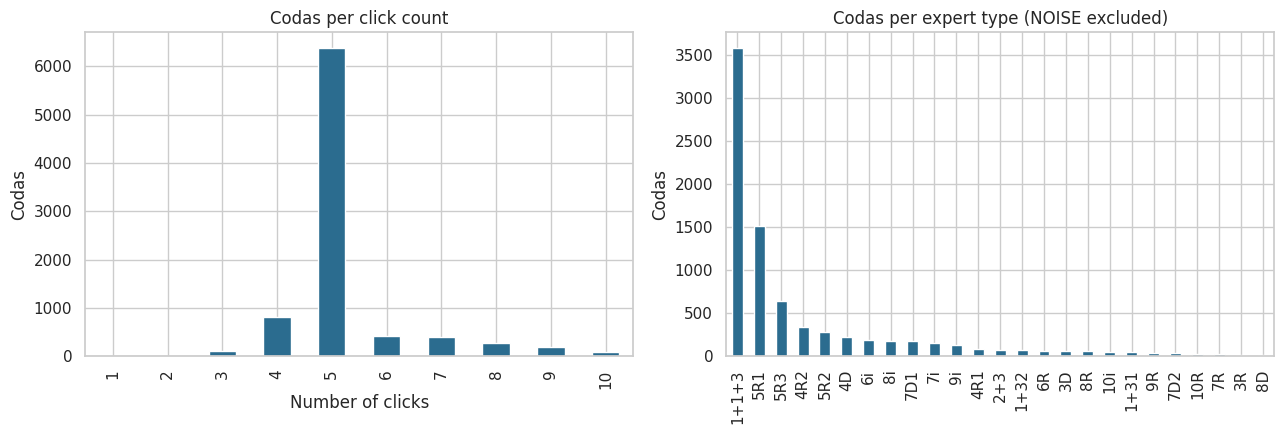

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
raw.nClicks.value_counts().sort_index().plot.bar(ax=axes[0], color="#2b6c8f")
axes[0].set(title="Codas per click count", xlabel="Number of clicks", ylabel="Codas")

top = raw[~raw.is_noise].CodaType.value_counts()
top.plot.bar(ax=axes[1], color="#2b6c8f")
axes[1].set(title="Codas per expert type (NOISE excluded)", xlabel="", ylabel="Codas")
axes[1].tick_params(axis="x", rotation=90)
plt.tight_layout(); plt.savefig(FIG / "01_counts.png", dpi=150); plt.show()

The dataset is **highly imbalanced**: 5-click codas make up ~73% of the data, and a single type (`1+1+3`) accounts for ~41%. This will dominate global metrics such as ARI, so results should also be reported per click count.

## 3. Clans have different repertoires

In [5]:
ct = pd.crosstab(raw[~raw.is_noise].CodaType, raw.Clan)
ct["EC1 share"] = (ct.EC1 / ct.sum(axis=1)).round(2)
ct.sort_values("EC1 share")

Clan,EC1,EC2,EC1 share
CodaType,,,
7R,0,23,0.00
5R3,19,623,0.03
6R,3,64,0.04
10R,11,21,0.34
9R,20,23,0.47
8R,41,19,0.68
4R2,303,37,0.89
10i,52,3,0.95
7i,145,6,0.96


Some types are clan markers (e.g. `5R3` is almost exclusively EC2, `1+1+3` and `5R1` almost exclusively EC1). Mixing clans would blur the structure, so the main analysis uses **EC1 only**, as in Sharma et al. Note that EC1 still contains a few codas of "EC2-style" types (e.g. 19 × `5R3`); this explains why we see 24 non-noise types in EC1 rather than the 21 usually reported.

## 4. Analysis subset

In [6]:
df = filter_codas(raw)   # EC1, no NOISE, >= 3 clicks
print(f"{len(df)} codas, {df.CodaType.nunique()} types, {df.Unit.nunique()} social units")

7268 codas, 24 types, 10 social units


## 5. Rhythm vs tempo: the core structure

Within the 5-click codas, plot each coda's normalised ICIs. Types with the same **shape** but different **speed** will overlap in rhythm space and separate only by duration.

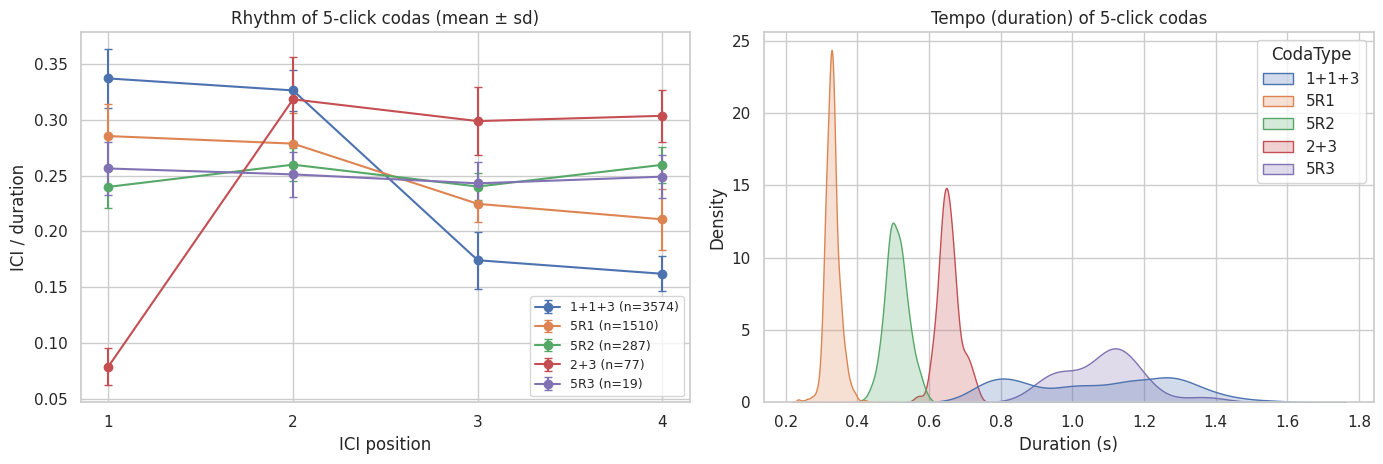

In [7]:
five = df[df.nClicks == 5]
R5 = rhythm_matrix(five)[:, :4]
order = five.CodaType.value_counts().index

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for t in order:
    m = (five.CodaType == t).to_numpy()
    mean = R5[m].mean(0); sd = R5[m].std(0)
    axes[0].errorbar(range(1, 5), mean, yerr=sd, marker="o", capsize=3, label=f"{t} (n={m.sum()})")
axes[0].set(title="Rhythm of 5-click codas (mean ± sd)", xlabel="ICI position", ylabel="ICI / duration")
axes[0].set_xticks(range(1, 5)); axes[0].legend(fontsize=9)

sns.kdeplot(data=five, x="Duration", hue="CodaType", hue_order=order, common_norm=False, ax=axes[1], fill=True, alpha=.25)
axes[1].set(title="Tempo (duration) of 5-click codas", xlabel="Duration (s)")
plt.tight_layout(); plt.savefig(FIG / "01_rhythm_tempo_5click.png", dpi=150); plt.show()

**Observations:**

- `5R2` and `5R3` have almost identical, flat (regular) rhythms and differ essentially only in **tempo** (~0.5 s vs ~1.1 s). `5R1` is close to them in rhythm (slightly decreasing ICIs) but much faster (~0.33 s). Rhythm alone cannot separate these types.
- `1+1+3` has a very distinctive rhythm (two long ICIs, then two short) but a **very wide duration distribution** (0.65–1.6 s), wider than any other type.
- `2+3` is clearly distinct in rhythm (a very short first ICI).

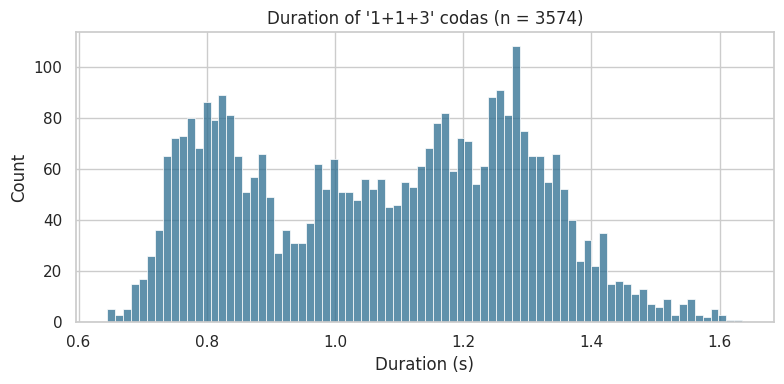

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(five[five.CodaType == "1+1+3"].Duration, bins=80, ax=ax, color="#2b6c8f")
ax.set(title="Duration of '1+1+3' codas (n = %d)" % (five.CodaType == "1+1+3").sum(), xlabel="Duration (s)")
plt.tight_layout(); plt.savefig(FIG / "01_113_duration.png", dpi=150); plt.show()

The distribution of `1+1+3` durations is clearly **multi-modal**, with peaks around ~0.8 s, ~1.0 s and ~1.25 s. A single expert label may therefore hide several discrete tempo classes, consistent with Sharma et al.'s description of tempo as a separate categorical feature. Notebook 02 tests whether an unsupervised method finds these sub-groups, and whether they could be a trivial artefact (e.g. different social units or recording years).

## 6. A 2-D view of all EC1 codas

UMAP on rhythm + log(duration). This is only a **visual aid**: UMAP can create or hide gaps, so no conclusion about clusters is drawn from it. Clustering is done in notebook 02 in the original feature space.

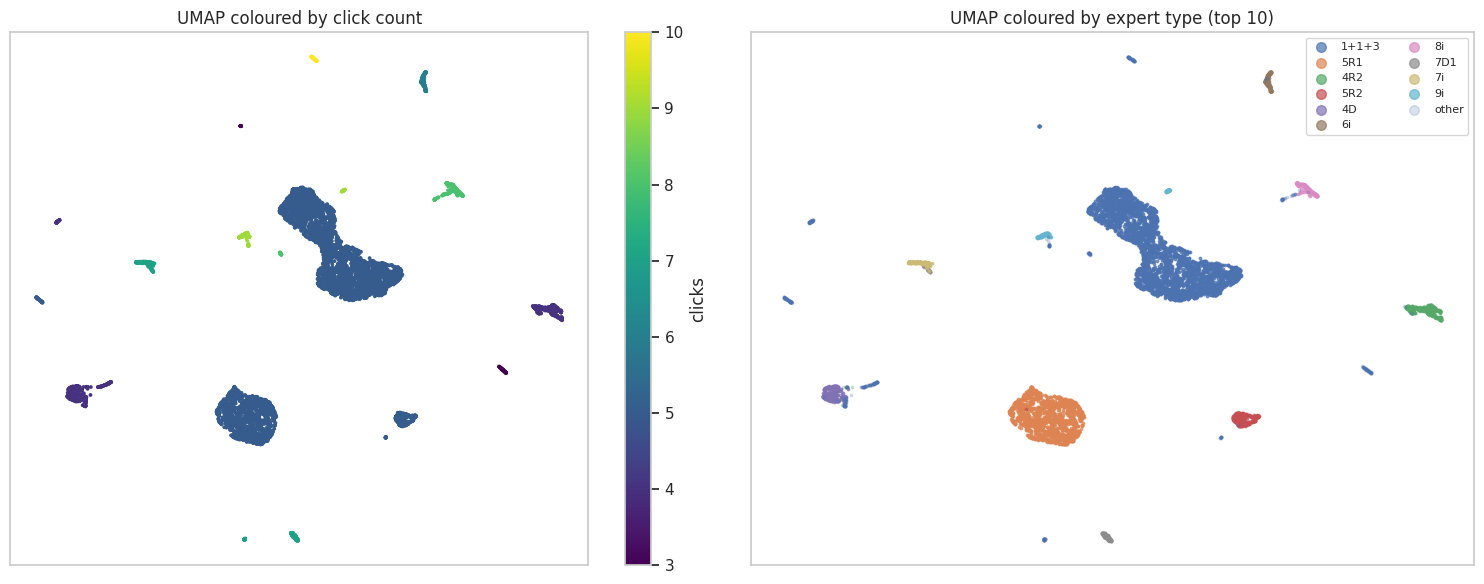

In [9]:
import umap
from sklearn.preprocessing import StandardScaler
X = np.c_[rhythm_matrix(df), np.log(df.Duration), df.nClicks]
emb = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42).fit_transform(StandardScaler().fit_transform(X))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sc = axes[0].scatter(*emb.T, c=df.nClicks, cmap="viridis", s=3)
plt.colorbar(sc, ax=axes[0], label="clicks"); axes[0].set_title("UMAP coloured by click count")
main = df.CodaType.value_counts().index[:10]
lab = df.CodaType.where(df.CodaType.isin(main), "other")
for t in list(main) + ["other"]:
    m = (lab == t).to_numpy()
    axes[1].scatter(*emb[m].T, s=3, label=t, alpha=.7 if t != "other" else .2)
axes[1].legend(markerscale=4, fontsize=8, ncol=2); axes[1].set_title("UMAP coloured by expert type (top 10)")
for a in axes: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.savefig(FIG / "01_umap.png", dpi=150); plt.show()

## Takeaways for the next step

1. Click count is a hard, observable boundary → cluster **within** each click count.
2. Include **tempo** alongside rhythm, otherwise regular types (`5R*`) collapse.
3. The imbalance means global scores will be dominated by 5-click codas → report per group too.
4. Expected "failure" worth watching: the algorithm may split `1+1+3` by tempo. That would not be an error but a finer structure than the expert labels.